# 97 — Test-Set Evaluation

Unbiased evaluation of trained checkpoints on the **fixed held-out test set** —
the images no cross-validation fold ever trained or validated on.

**This notebook is run once.** Every epoch-selection and design decision was
already made on the validation sets.

### Protocol

- The fixed test images come from each fold's training history
  (`results/<run>_history.npy`, key `test_patients`).
- Prediction and scoring happen at **labelled pixels only** (`label > 0`).
- Metrics are pooled per fold and aggregated across folds as **median ± std**.

### What comes from the `brainvision` package

| Step | Package function |
|---|---|
| Canonical run / checkpoint names | `brainvision.utils.build_run_name` |
| Load a fold's training history (and its `test_patients` split) | `brainvision.history.load_history` |
| Device selection / cache | `brainvision.device.get_device`, `print_device_info`, `empty_device_cache`, `supports_pin_memory` |
| Pixel / patch extraction (labelled pixels, 0-indexed targets, reflect-pad) | `brainvision.data.HSIPixelDataset`, `HSIPatchDataset` |
| Per-fold metrics (pooled confusion matrix, F1, sensitivity, specificity, OA) | `brainvision.metrics.compute_metrics` |
| Fold aggregation (median ± std, per-class) | `brainvision.metrics.aggregate_fold_metrics` |
| Formatted console output | `brainvision.metrics.print_metrics`, `print_aggregate` |

`compute_metrics` is sklearn-backed — the same path `07_evaluation.ipynb` uses,
so these numbers sit beside the existing ones consistently. The notebook only
adds: the per-fold loop, the median-fold confusion-matrix figure, and the
markdown / `.npz` export.

The experiment is configured exactly as in `06_training.ipynb` /
`07_evaluation.ipynb` — set `MODEL`, `LOSS_FN`, `STRATEGY`, `REDUCE_PIXELS`,
`N_FOLDS`, `TARGET_FOLDS` and run top to bottom.


In [152]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Imports
# ═══════════════════════════════════════════════════════════════════════════════
import time
from datetime import date
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from IPython.display import Markdown, display

from brainvision.constants import *          # N_CLASSES, PATCH_SIZE, CLASS_NAMES, paths, SF_*, ...
from brainvision.models import (
    Baseline1DDNN, FabeloDNN, HuEtAl1DCNN, LeeEtAl2DCNN, HamidaEtAl3DCNN,
    HybridSN, SpectralFormer, Fabelo2DCNN, Simple2DCNN,
)
from brainvision.utils import build_run_name
from brainvision.history import load_history
from brainvision.device import (
    get_device, print_device_info, empty_device_cache, supports_pin_memory,
)
from brainvision.data import HSIPixelDataset, HSIPatchDataset
from brainvision.metrics import (
    compute_metrics, aggregate_fold_metrics, print_metrics, print_aggregate,
)

In [153]:
# ══════════════════════════════════════════════════════════════════════════════
#                        CONFIGURE EXPERIMENT HERE
# ══════════════════════════════════════════════════════════════════════════════

MODEL    = "1D-CNN"      # "1D-NN" | "1D-NN-Fabelo" | "1D-CNN" | "2D-CNN" | "3D-CNN" | "SF"
LOSS_FN  = "CE"                 # "CE" | "FL" | "DL" | "UFL"
REDUCE_PIXELS = True            # apply K-Means reduction to training set

STRATEGY = "vp_fabelo"          # "vp1" | "vp2" | "vp3" | "lopo" | "vp_fabelo"
N_FOLDS  = 5                    # used for vp3 and lopo only; vp_fabelo always uses 5 folds
TARGET_FOLDS = -1              # -1 = all folds; an int = only that fold; a list = those folds

In [154]:
# ── Model registry (mirrors 06_training.ipynb) ─────────────────────────────
MODEL_REGISTRY = {
    '1D-NN': lambda: Baseline1DDNN(
        input_channels=N_DECIMATED_BANDS, n_classes=N_CLASSES,
        dropout=True, dropout_rate=DROPOUT_RATE),
    '1D-NN-Fabelo': lambda: FabeloDNN(
        input_channels=N_DECIMATED_BANDS, n_classes=N_CLASSES),
    '1D-CNN': lambda: HuEtAl1DCNN(
        input_channels=N_DECIMATED_BANDS, n_classes=N_CLASSES),
    '2D-CNN': lambda: LeeEtAl2DCNN(
        input_channels=N_DECIMATED_BANDS, n_classes=N_CLASSES, patch_size=PATCH_SIZE),
    '2D-CNN-Fabelo': lambda: Fabelo2DCNN(
        input_channels=N_DECIMATED_BANDS, n_classes=N_CLASSES, patch_size=PATCH_SIZE),
    '2D-CNN-Simple': lambda: Simple2DCNN(
        input_channels=N_DECIMATED_BANDS, n_classes=N_CLASSES, patch_size=PATCH_SIZE),
    '3D-CNN': lambda: HamidaEtAl3DCNN(
        input_channels=N_DECIMATED_BANDS, n_classes=N_CLASSES, patch_size=PATCH_SIZE),
    'HybridSN': lambda: HybridSN(
        input_channels=N_DECIMATED_BANDS, n_classes=N_CLASSES, patch_size=PATCH_SIZE),
    'SpectralFormer': lambda: SpectralFormer(
        input_channels=N_DECIMATED_BANDS, n_classes=N_CLASSES,
        near_band=SF_NEAR_BAND, dim=SF_DIM, depth=SF_DEPTH, heads=SF_HEADS,
        dim_head=SF_DIM_HEAD, mlp_dim=SF_MLP_DIM, dropout=SF_DROPOUT,
        emb_dropout=SF_EMB_DROPOUT, mode=SF_MODE),
}
PATCH_MODELS = {'2D-CNN', '3D-CNN', 'HybridSN', '2D-CNN-Fabelo', '2D-CNN-Simple'}

assert MODEL in MODEL_REGISTRY, f"Unknown MODEL {MODEL!r}. Choose from {list(MODEL_REGISTRY)}"

KIND = "patch" if MODEL in PATCH_MODELS else "pixel"

# ── Fold list from N_FOLDS / TARGET_FOLDS (same logic as 06_training.ipynb) ──
_whitelist = set()
if TARGET_FOLDS is not None:
    if isinstance(TARGET_FOLDS, int) and TARGET_FOLDS != -1:
        _whitelist.add(TARGET_FOLDS)
    elif isinstance(TARGET_FOLDS, (list, tuple)):
        _whitelist.update(TARGET_FOLDS)
FOLDS = [f for f in range(1, N_FOLDS + 1) if not _whitelist or f in _whitelist]

# ── Derived paths / batching ──────────────────────────────────────────────
CKPT_DIR  = Path(CHECKPOINTS_DIR)
RES_DIR   = Path(RESULTS_DIR)
PROC_DIRS = [Path(p) for p in PROCESSED_DIRS.values()]

BATCH_PIXELS  = 8192            # DataLoader batch for the 1D (pixel) dataset
BATCH_PATCHES = 1024           # DataLoader batch for the 2D (patch) dataset — OOM guard

# Short stem for the export filenames (build_run_name with no fold).
RUN_STEM = build_run_name(model=MODEL, loss_fn=LOSS_FN, strategy=STRATEGY,
                          fold=None, reduce_pixels=REDUCE_PIXELS)

print(f"  Model      : {MODEL}  ({KIND})")
print(f"  Loss       : {LOSS_FN}")
print(f"  Strategy   : {STRATEGY}")
print(f"  Folds      : {FOLDS}")
print(f"  Patch size : {PATCH_SIZE if KIND == 'patch' else '-- (pixel model)'}")
print(f"  Export stem: {RUN_STEM}")

  Model      : 1D-CNN  (pixel)
  Loss       : CE
  Strategy   : vp_fabelo
  Folds      : [1, 2, 3, 4, 5]
  Patch size : -- (pixel model)
  Export stem: 1dcnn_ce_bal_vpfabelo


In [155]:
# ── DEVICE ──────────────────────────────────────────────────────────────────
# get_device() picks CUDA -> MPS -> CPU. On Apple Silicon with no CUDA this
# resolves to MPS — the backend these checkpoints were trained on.
DEVICE     = get_device()
PIN_MEMORY = supports_pin_memory(DEVICE)     # True only for CUDA
print_device_info(DEVICE)

  Device     : MPS
  Name       : Apple Silicon (MPS)
  Memory     : 12,713 MB total  | N/A free  | N/A used


## Discovery & verification

Cheap checks that run **before** the expensive inference — load each fold's
history via `brainvision.history.load_history`, recover the fixed test split,
resolve it to files, locate every checkpoint, confirm the label coding.
Anything wrong raises here rather than halfway through a long run.


In [156]:
# ── DISCOVERY & VERIFICATION ────────────────────────────────────────────────
TEST_SPLIT_KEY = "test_patients"          # key inside results/<run>_history.npy
UNLABELLED     = 0                        # label value for unlabelled pixels


def _cfg(fold: int) -> dict:
    return dict(model=MODEL, loss=LOSS_FN, strategy=STRATEGY,
               fold=fold, reduce_pixels=REDUCE_PIXELS)


# 1. Load every fold's history (brainvision.history.load_history builds the
#    run name and returns the dict + 'run_name', or None if the file is absent).
HISTORIES = {}
for fold in FOLDS:
    h = load_history(_cfg(fold), RESULTS_DIR)
    if h is None:
        raise FileNotFoundError(
            f"No training history for fold {fold} in {RESULTS_DIR}/ "
            f"(MODEL={MODEL!r}, LOSS_FN={LOSS_FN!r}, STRATEGY={STRATEGY!r}, "
            f"REDUCE_PIXELS={REDUCE_PIXELS}). load_history printed the expected filename."
        )
    HISTORIES[fold] = h

RUN_NAMES = {fold: h["run_name"] for fold, h in HISTORIES.items()}


# 2. Recover the fixed test split from each history and confirm the folds agree.
def get_test_ids(history: dict) -> list:
    if TEST_SPLIT_KEY not in history:
        raise KeyError(
            f"Test-split key {TEST_SPLIT_KEY!r} not in "
            f"{history.get('run_name', '?')}_history.npy. "
            f"Available keys: {sorted(history.keys())}"
        )
    return list(history[TEST_SPLIT_KEY])


test_ids_per_fold = {fold: get_test_ids(h) for fold, h in HISTORIES.items()}
if len({tuple(v) for v in test_ids_per_fold.values()}) != 1:
    raise RuntimeError(
        "Fixed test split differs between folds:\n" +
        "\n".join(f"  fold {f}: {v}" for f, v in test_ids_per_fold.items())
    )
TEST_IDS = sorted(test_ids_per_fold[FOLDS[0]])
print(f"  Test split : {len(TEST_IDS)} images, identical across folds {FOLDS}")
print(f"  {TEST_IDS}")


# 3. Resolve each bare image ID to a preprocessed .npz across the campaign dirs.
def resolve_npz(image_id: str) -> Path:
    hits = [d / f"{image_id}.npz" for d in PROC_DIRS
            if (d / f"{image_id}.npz").exists()]
    if not hits:
        raise FileNotFoundError(
            f"Test image {image_id!r} not found under any of "
            f"{[str(d) for d in PROC_DIRS]}"
        )
    if len(hits) > 1:
        raise RuntimeError(f"Test image {image_id!r} is ambiguous — found in {hits}")
    return hits[0]


TEST_PATHS = {img: resolve_npz(img) for img in TEST_IDS}
print("\n  Resolved test images:")
for img, p in TEST_PATHS.items():
    print(f"     {img}  ->  {p.parent.name}/{p.name}")


# 4. Confirm every fold checkpoint exists.
CKPT_PATHS = {fold: CKPT_DIR / f"{rn}.pt" for fold, rn in RUN_NAMES.items()}
missing = [str(p) for p in CKPT_PATHS.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing checkpoint(s):\n  " + "\n  ".join(missing))
print(f"\n  Located {len(CKPT_PATHS)} checkpoints in {CKPT_DIR}/")


# 5. For Fabelo2DCNN the classifier width encodes the training patch size
#    (flat = 128 * floor(P/2)**2). Verify PATCH_SIZE matches the checkpoint so
#    HSIPatchDataset reconstructs patches exactly as during training.
if MODEL == "2D-CNN-Fabelo":
    sd = torch.load(CKPT_PATHS[FOLDS[0]], map_location="cpu", weights_only=True)
    flat     = sd["classifier.weight"].shape[1]
    expected = N_DECIMATED_BANDS * (PATCH_SIZE // 2) ** 2
    if flat != expected:
        raise RuntimeError(
            f"Patch-size mismatch: checkpoint classifier width {flat} implies "
            f"floor(P/2)**2 = {flat // N_DECIMATED_BANDS}, but PATCH_SIZE={PATCH_SIZE} "
            f"gives {expected}. Adjust constants.PATCH_SIZE."
        )
    print(f"  Patch size {PATCH_SIZE} confirmed against checkpoint "
          f"(classifier width {flat})")


# 6. Confirm label coding: 0 = unlabelled, 1..4 = NT, TT, BV, BG.
label_values = set()
for p in TEST_PATHS.values():
    label_values |= set(int(v) for v in np.unique(np.load(p)["labels"]))
print(f"\n  Label values present across test set: {sorted(label_values)}")
assert label_values <= set(range(N_CLASSES + 1)), f"Unexpected label values: {label_values}"
assert UNLABELLED in label_values, "Expected unlabelled pixels (0) in the test set"
print("  Label coding OK (0 = unlabelled, 1=NT 2=TT 3=BV 4=BG)")

  Test split : 15 images, identical across folds [1, 2, 3, 4, 5]
  ['012-01', '012-02', '019-01', '022-01', '022-02', '022-03', '037-01', '037-02', '037-03', '037-04', '038-01', '042-01', '042-02', '042-03', '053-01']

  Resolved test images:
     012-01  ->  first_campaign/012-01.npz
     012-02  ->  first_campaign/012-02.npz
     019-01  ->  first_campaign/019-01.npz
     022-01  ->  first_campaign/022-01.npz
     022-02  ->  first_campaign/022-02.npz
     022-03  ->  first_campaign/022-03.npz
     037-01  ->  second_campaign/037-01.npz
     037-02  ->  second_campaign/037-02.npz
     037-03  ->  second_campaign/037-03.npz
     037-04  ->  second_campaign/037-04.npz
     038-01  ->  second_campaign/038-01.npz
     042-01  ->  second_campaign/042-01.npz
     042-02  ->  second_campaign/042-02.npz
     042-03  ->  second_campaign/042-03.npz
     053-01  ->  third_campaign/053-01.npz

  Located 5 checkpoints in ../checkpoints/

  Label values present across test set: [0, 1, 2, 3, 4]
  L

## Load the fixed test images

Loaded once, wrapped as `brainvision` *patient* dicts (`processed`, `labels`)
so the package dataset classes can do the extraction.


In [157]:
# ── LOAD TEST IMAGES (once) ─────────────────────────────────────────────────
def load_test_patients() -> list:
    patients = []
    for img_id in TEST_IDS:
        d = np.load(TEST_PATHS[img_id])
        patients.append({
            "id":        img_id,
            "processed": d["processed"].astype(np.float32),   # (H, W, 128) in [0, 1]
            "labels":    d["labels"].astype(np.int64),        # (H, W)  0..4
        })
    return patients


TEST_PATIENTS = load_test_patients()

# Per-image summary — name, shape, labelled-pixel count, classes present.
print(f"  {'image':<10} {'H x W':<13} {'bands':>5} {'labelled':>10}   classes present")
print(f"  {'-' * 62}")
total_labelled = 0
for pt in TEST_PATIENTS:
    H, W, C = pt["processed"].shape
    mask    = pt["labels"] > UNLABELLED
    n_lab   = int(mask.sum())
    total_labelled += n_lab
    present = ", ".join(CLASS_NAMES_SHORT[int(v)] for v in np.unique(pt["labels"][mask]))
    print(f"  {pt['id']:<10} {f'{H} x {W}':<13} {C:>5} {n_lab:>10,}   {present}")
print(f"  {'-' * 62}")
print(f"  {'TOTAL':<10} {'':<13} {'':>5} {total_labelled:>10,}")

  image      H x W         bands   labelled   classes present
  --------------------------------------------------------------
  012-01     443 x 497       128     15,753   NT, TT, BV, BG
  012-02     445 x 498       128     24,464   NT, TT, BV, BG
  019-01     601 x 535       128      9,782   NT, BV, BG
  022-01     597 x 527       128      7,547   NT, BV, BG
  022-02     611 x 527       128      8,854   NT, BV
  022-03     592 x 471       128         96   TT
  037-01     434 x 453       128     26,404   NT, BV, BG
  037-02     315 x 526       128      7,538   NT, BV, BG
  037-03     290 x 422       128      3,608   NT, TT
  037-04     280 x 444       128        330   TT
  038-01     497 x 490       128     28,704   NT, TT, BV, BG
  042-01     629 x 646       128     40,512   NT, BV, BG
  042-02     623 x 584       128     28,956   NT, TT, BV, BG
  042-03     650 x 582       128      4,481   NT, TT, BV, BG
  053-01     546 x 446       128     39,516   NT, TT, BG
  --------------------

## Test dataset and per-fold inference

The dataset is built **once** — the 15 images are identical for every fold, only
the checkpoint changes. `HSIPixelDataset` / `HSIPatchDataset` keep labelled
pixels only and return 0-indexed targets; `HSIPatchDataset` reflect-pads and
extracts patches lazily so a `DataLoader` batches the inference.


In [158]:
# ── TEST DATASET (built once) ──────────────────────────────────────────────
if KIND == "pixel":
    test_ds = HSIPixelDataset(TEST_PATIENTS)
    BATCH   = BATCH_PIXELS
else:
    test_ds = HSIPatchDataset(TEST_PATIENTS, patch_size=PATCH_SIZE,
                              balance=False, augment=False)   # eval: no aug, no balance
    BATCH   = BATCH_PATCHES

test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                         num_workers=0, pin_memory=PIN_MEMORY)
print(f"  {len(test_ds):,} labelled samples  ·  batch size {BATCH}")


@torch.no_grad()
def predict(model: torch.nn.Module) -> tuple:
    """Run `model` over the whole test loader.

    Returns (preds, targets), both 0-indexed (0=NT .. 3=BG) and pooled across
    all test images — ready for brainvision.metrics.compute_metrics.
    """
    model.eval()
    preds, targets = [], []
    for X, y in test_loader:
        preds.append(model(X.to(DEVICE)).argmax(1).cpu().numpy())
        targets.append(y.numpy())
    return np.concatenate(preds), np.concatenate(targets)

  246,545 labelled samples  ·  batch size 8192


In [159]:
# ── RUN: one checkpoint per fold ───────────────────────────────────────────
fold_metrics = []                 # list of compute_metrics() dicts, one per fold
fold_seconds = {}
targets_ref  = None               # the fixed dataset -> targets identical every fold

for fold in FOLDS:
    run_name = RUN_NAMES[fold]
    model = MODEL_REGISTRY[MODEL]().to(DEVICE)
    model.load_state_dict(
        torch.load(CKPT_PATHS[fold], map_location=DEVICE, weights_only=True)
    )

    t0 = time.perf_counter()
    preds, targets = predict(model)
    dt = time.perf_counter() - t0

    if targets_ref is None:
        targets_ref = targets
    else:
        assert np.array_equal(targets, targets_ref), \
            "test targets changed between folds — dataset is not stable"

    m = compute_metrics(targets, preds, run_name)     # pooled confusion matrix + metrics
    fold_metrics.append(m)
    fold_seconds[fold] = dt

    print_metrics(m)
    print(f"  ({dt:.1f}s wall, {int(m['confusion_matrix'].sum()):,} labelled pixels)")

    del model
    empty_device_cache(DEVICE)

print(f"\n  Total inference time: {sum(fold_seconds.values()):.1f}s")


═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — 1dcnn_ce_bal_fold1_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.8078
  Macro F1  (all classes)    : 0.7480
  Macro F1  (no BG)          : 0.7325  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7480
  Macro Dice (no BG)         : 0.7325

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8613       0.9376   0.8877   0.8877
  Tumour Tissue (TT)              0.8301       0.9331   0.5561   0.5561  ← clinical priority
  Blood Vessel (BV)               0.7697       0.9440   0.7538   0.7538
  Background (BG)                 0.7531       0.9286   0.7946   0.7946
  ────────────────────────────────────────────────────────────────────
  Mean                            0.8036       0.9358   0.748

## Aggregate across folds — median ± std

`brainvision.metrics.aggregate_fold_metrics` reduces the per-fold dicts with
`np.median` and `np.std` (population std, `ddof=0`) — the convention used
throughout the training logs.


In [160]:
# ── AGGREGATE (brainvision.metrics) ───────────────────────────────────────
agg = aggregate_fold_metrics(fold_metrics)
print_aggregate(agg, model=MODEL, loss_fn=LOSS_FN, strategy=STRATEGY)


═════════════════════════════════════════════════════════════════
  AGGREGATE — 1D-CNN × CE × vp_fabelo
  5 folds
═════════════════════════════════════════════════════════════════
  Macro F1  (all)    : 74.8 ± 1.9%
  Macro F1  (no BG)  : 73.3 ± 2.0%  ← vs Fabelo 70.2 ± 7.9%
  Macro Dice (all)   : 74.8 ± 1.9%
  Macro Dice (no BG) : 73.3 ± 2.0%
  OA                 : 81.5 ± 1.3%

  Class      Sens     ±     Spec     ±      Dice     ±
  ───────────────────────────────────────────────────────
  NT        86.7%   ± 0.5%     92.7%   ± 1.1%     88.4%   ± 0.7%
  TT        65.1%   ± 7.7%     95.2%   ± 1.3%     55.6%   ± 4.4%  ← clinical priority
  BV        86.7%   ± 6.9%     92.9%   ± 1.4%     78.3%   ± 1.8%
  BG        75.0%   ± 1.5%     94.3%   ± 1.4%     79.5%   ± 1.6%

  Per-fold F1 (no BG)  : ['73.3%', '74.6%', '77.1%', '73.3%', '71.2%']
  Per-fold Dice (no BG): ['73.3%', '74.6%', '77.1%', '73.3%', '71.2%']


In [161]:
# ── MARKDOWN TABLES (for the report export) ───────────────────────────────
# Per-class F1 == per-class Dice for a one-vs-rest confusion matrix, so
# compute_metrics()'s `dice` array doubles as per-class F1 here.
CLASSES = ["NT", "TT", "BV", "BG"]     # 0-indexed order used by compute_metrics
TT_IDX  = 1                            # Tumour Tissue


def to_md_table(header, rows) -> str:
    out = ["| " + " | ".join(header) + " |",
           "|" + "|".join("---" for _ in header) + "|"]
    out += ["| " + " | ".join(r) + " |" for r in rows]
    return "\n".join(out)


def p1(x) -> str:
    return "nan" if x != x else f"{x * 100:.1f}"


def pm(med, std) -> str:
    return "nan" if med != med else f"{med * 100:.1f} ± {std * 100:.1f}"


per_fold_md = to_md_table(
    ["Fold", "Macro F1", "F1 no-BG", "OA", "TT Sens",
     "NT F1", "TT F1", "BV F1", "BG F1", "Time (s)"],
    [
        [str(fold), p1(m["macro_f1"]), p1(m["macro_f1_no_bg"]), p1(m["oa"]),
         p1(m["sensitivity"][TT_IDX]),
         *[p1(m["dice"][c]) for c in range(N_CLASSES)],
         f"{fold_seconds[fold]:.1f}"]
        for fold, m in zip(FOLDS, fold_metrics)
    ],
)

summary_md = to_md_table(
    ["Metric", "Median ± Std (%)"],
    [
        ["Macro F1 (all classes)",
         pm(agg["macro_f1_median"], agg["macro_f1_std"])],
        ["Macro F1 (excl. Background)",
         pm(agg["macro_f1_no_bg_median"], agg["macro_f1_no_bg_std"]) + "  ← primary"],
        ["Overall accuracy",
         pm(agg["oa_median"], agg["oa_std"])],
        ["Tumour Tissue sensitivity",
         pm(agg["per_class_sens_median"]["TT"], agg["per_class_sens_std"]["TT"])
         + "  ← clinical priority"],
    ],
)

per_class_md = to_md_table(
    ["Class", "Sensitivity", "Specificity", "F1"],
    [
        [CLASS_NAMES[i + 1] + ("  ← clinical priority" if code == "TT" else ""),
         pm(agg["per_class_sens_median"][code], agg["per_class_sens_std"][code]),
         pm(agg["per_class_spec_median"][code], agg["per_class_spec_std"][code]),
         pm(agg["per_class_dice_median"][code], agg["per_class_dice_std"][code])]
        for i, code in enumerate(CLASSES)
    ],
)

display(Markdown("**Per-fold results (%)**\n\n" + per_fold_md))
display(Markdown("**Aggregate (median ± std, %)**\n\n" + summary_md))
display(Markdown("**Per-class aggregate (median ± std, %)**\n\n" + per_class_md))
print("Per-fold Macro F1 no-BG :", [f"{v * 100:.1f}%" for v in agg["per_fold_f1_no_bg"]])

**Per-fold results (%)**

| Fold | Macro F1 | F1 no-BG | OA | TT Sens | NT F1 | TT F1 | BV F1 | BG F1 | Time (s) |
|---|---|---|---|---|---|---|---|---|---|
| 1 | 74.8 | 73.3 | 80.8 | 83.0 | 88.8 | 55.6 | 75.4 | 79.5 | 1.4 |
| 2 | 76.1 | 74.6 | 81.9 | 70.9 | 88.4 | 57.0 | 78.3 | 80.6 | 1.1 |
| 3 | 78.6 | 77.1 | 84.0 | 65.1 | 89.8 | 61.6 | 80.0 | 82.9 | 1.1 |
| 4 | 74.8 | 73.3 | 81.5 | 63.6 | 88.4 | 51.5 | 79.9 | 79.4 | 1.0 |
| 5 | 72.9 | 71.2 | 80.1 | 61.9 | 87.8 | 48.9 | 76.9 | 78.1 | 1.0 |

**Aggregate (median ± std, %)**

| Metric | Median ± Std (%) |
|---|---|
| Macro F1 (all classes) | 74.8 ± 1.9 |
| Macro F1 (excl. Background) | 73.3 ± 2.0  ← primary |
| Overall accuracy | 81.5 ± 1.3 |
| Tumour Tissue sensitivity | 65.1 ± 7.7  ← clinical priority |

**Per-class aggregate (median ± std, %)**

| Class | Sensitivity | Specificity | F1 |
|---|---|---|---|
| Normal Tissue (NT) | 86.7 ± 0.5 | 92.7 ± 1.1 | 88.4 ± 0.7 |
| Tumour Tissue (TT)  ← clinical priority | 65.1 ± 7.7 | 95.2 ± 1.3 | 55.6 ± 4.4 |
| Blood Vessel (BV) | 86.7 ± 6.9 | 92.9 ± 1.4 | 78.3 ± 1.8 |
| Background (BG) | 75.0 ± 1.5 | 94.3 ± 1.4 | 79.5 ± 1.6 |

Per-fold Macro F1 no-BG : ['73.3%', '74.6%', '77.1%', '73.3%', '71.2%']


## Confusion matrix — median fold

The *median fold* is the one whose primary metric (Macro F1 excl. Background)
is the median across folds.


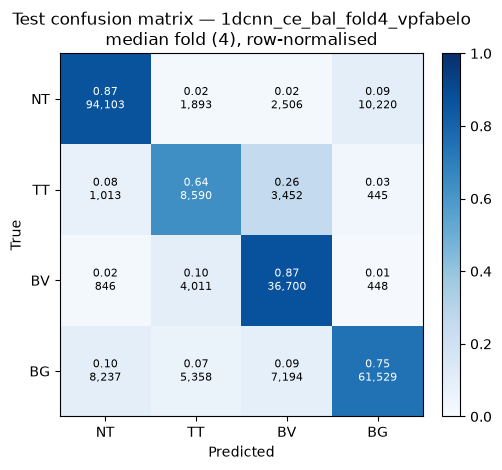

  median fold = 4   saved -> ../results/test_eval_1dcnn_ce_bal_vpfabelo_cm.png


In [162]:
# ── CONFUSION MATRIX HEATMAP — MEDIAN FOLD ──────────────────────────────────
order       = sorted(range(len(FOLDS)), key=lambda k: fold_metrics[k]["macro_f1_no_bg"])
mid         = order[len(order) // 2]
median_fold = FOLDS[mid]

cm      = fold_metrics[mid]["confusion_matrix"]        # from compute_metrics (rows=true)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
labels  = [CLASS_NAMES_SHORT[i + 1] for i in range(N_CLASSES)]

fig, ax = plt.subplots(figsize=(5.6, 4.8))
hm = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES), labels)
ax.set_yticks(range(N_CLASSES), labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Test confusion matrix — {RUN_NAMES[median_fold]}\n"
             f"median fold ({median_fold}), row-normalised")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}\n{cm[i, j]:,}",
                ha="center", va="center", fontsize=8,
                color="white" if cm_norm[i, j] > 0.5 else "black")
fig.colorbar(hm, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

cm_png = RES_DIR / f"test_eval_{RUN_STEM}_cm.png"
fig.savefig(cm_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"  median fold = {median_fold}   saved -> {cm_png}")

## Export

- `results/test_eval_<stem>.md` — tables ready to paste beside the
  `docs/TRAINING_LOG_*` tables.
- `results/test_eval_<stem>.npz` — the raw per-fold confusion matrices plus
  metadata, so any metric can be re-derived later without re-running inference.


In [163]:
# ── EXPORT ──────────────────────────────────────────────────────────────────
md_path  = RES_DIR / f"test_eval_{RUN_STEM}.md"
npz_path = RES_DIR / f"test_eval_{RUN_STEM}.npz"

meta_md = to_md_table(
    ["field", "value"],
    [
        ["Model",           f"{MODEL} ({KIND})"],
        ["Loss",            LOSS_FN],
        ["Strategy",        STRATEGY],
        ["Folds",           ", ".join(map(str, FOLDS))],
        ["Patch size",      str(PATCH_SIZE) if KIND == "patch" else "--"],
        ["Test images",     f"{len(TEST_IDS)} ({', '.join(TEST_IDS)})"],
        ["Labelled pixels", f"{total_labelled:,}"],
        ["Median fold",     str(median_fold)],
        ["Device",          str(DEVICE)],
        ["Date",            date.today().isoformat()],
    ],
)

report = "\n\n".join([
    f"# Test-set evaluation — {RUN_STEM}",
    meta_md,
    "Metrics from `brainvision.metrics.compute_metrics` (pooled per-fold "
    "confusion matrix, labelled pixels only). Aggregate = median ± population "
    "std across folds.",
    "## Per-fold results (%)\n\n"          + per_fold_md,
    "## Aggregate (median ± std, %)\n\n"   + summary_md,
    "## Per-class aggregate (median ± std, %)\n\n" + per_class_md,
    f"![confusion matrix — median fold](test_eval_{RUN_STEM}_cm.png)",
    "",
])
md_path.write_text(report)

np.savez(
    npz_path,
    run_stem         = RUN_STEM,
    model            = MODEL,
    loss             = LOSS_FN,
    strategy         = STRATEGY,
    kind             = KIND,
    folds            = np.array(FOLDS),
    patch_size       = PATCH_SIZE,
    test_ids         = np.array(TEST_IDS),
    class_labels     = np.array(CLASSES),
    median_fold      = median_fold,
    per_fold_f1_no_bg = np.array(agg["per_fold_f1_no_bg"]),
    per_fold_f1_all   = np.array(agg["per_fold_f1_all"]),
    per_fold_oa       = np.array(agg["per_fold_oa"]),
    **{f"cm_fold{fold}": m["confusion_matrix"]
       for fold, m in zip(FOLDS, fold_metrics)},
)

print(f"  wrote {md_path}")
print(f"  wrote {npz_path}")
print(f"  wrote {cm_png}")
print()
print(report)

  wrote ../results/test_eval_1dcnn_ce_bal_vpfabelo.md
  wrote ../results/test_eval_1dcnn_ce_bal_vpfabelo.npz
  wrote ../results/test_eval_1dcnn_ce_bal_vpfabelo_cm.png

# Test-set evaluation — 1dcnn_ce_bal_vpfabelo

| field | value |
|---|---|
| Model | 1D-CNN (pixel) |
| Loss | CE |
| Strategy | vp_fabelo |
| Folds | 1, 2, 3, 4, 5 |
| Patch size | -- |
| Test images | 15 (012-01, 012-02, 019-01, 022-01, 022-02, 022-03, 037-01, 037-02, 037-03, 037-04, 038-01, 042-01, 042-02, 042-03, 053-01) |
| Labelled pixels | 246,545 |
| Median fold | 4 |
| Device | mps |
| Date | 2026-09-01 |

Metrics from `brainvision.metrics.compute_metrics` (pooled per-fold confusion matrix, labelled pixels only). Aggregate = median ± population std across folds.

## Per-fold results (%)

| Fold | Macro F1 | F1 no-BG | OA | TT Sens | NT F1 | TT F1 | BV F1 | BG F1 | Time (s) |
|---|---|---|---|---|---|---|---|---|---|
| 1 | 74.8 | 73.3 | 80.8 | 83.0 | 88.8 | 55.6 | 75.4 | 79.5 | 1.4 |
| 2 | 76.1 | 74.6 | 81.9 | 70